### Loading libraries

In [2]:
import pandas as pd
import numpy as np
from pybiomart import Dataset
import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri, default_converter
from rpy2.robjects.packages import importr
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import warnings

### Loading data

In [335]:
mrna_data = pd.read_csv('../../data/raw_data/tcga_paad_mrna_tpm_raw.csv')

In [336]:
mirna_data = pd.read_csv('../../data/raw_data/tcga_paad_mirna_raw.csv')

In [337]:
meth_data = pd.read_csv('../../data/raw_data/tcga_paad_dnamethylation_raw.csv')

In [338]:
clinical_data = pd.read_csv('../../data/raw_data/tcga_paad_clinical_raw.csv', sep=',')

### Dimension of datasets

In [339]:
print("mRNA data shape:", mrna_data.shape)

mRNA data shape: (60660, 184)


In [340]:
print("miRNA data shape:", mirna_data.shape)

miRNA data shape: (1881, 551)


In [341]:
print("Methylation data shape:", meth_data.shape)

Methylation data shape: (485577, 196)


In [342]:
print("Clinical data shape:", clinical_data.shape)

Clinical data shape: (187, 77)


### mRNA Preprocessing

In [343]:
mrna_data.head(2)

,Unnamed: 0,TCGA-HZ-A8P1-01A-11R-A37L-07,TCGA-FB-AAPS-01A-12R-A39D-07,TCGA-IB-AAUN-01A-12R-A38C-07,TCGA-3A-A9I7-01A-21R-A38C-07,TCGA-FB-AAPY-01A-11R-A41B-07,TCGA-2J-AABP-01A-11R-A41B-07,TCGA-2L-AAQM-01A-11R-A39D-07,TCGA-HZ-8519-01A-11R-2404-07,TCGA-PZ-A5RE-01A-11R-A32O-07,...,TCGA-HZ-8005-01A-11R-2204-07,TCGA-HV-A5A6-01A-11R-A26U-07,TCGA-F2-A44H-01A-11R-A26U-07,TCGA-LB-A7SX-01A-11R-A33R-07,TCGA-OE-A75W-01A-12R-A32O-07,TCGA-HZ-7925-01A-11R-2156-07,TCGA-FB-AAPZ-01A-11R-A41B-07,TCGA-IB-7646-01A-11R-2156-07,TCGA-US-A776-01A-13R-A33R-07,TCGA-IB-7887-01A-11R-2156-07
0,ENSG00000000003.15,17.6270,23.7376,28.3285,23.2157,17.9026,31.907,4.7895,26.8066,16.7029,...,26.9536,51.6905,23.039,27.7489,19.3546,25.2659,33.7614,63.0141,22.2781,31.633
1,ENSG00000000005.6,0.0535,3.3526,0.1050,0.0000,0.1162,0.000,0.0985,4.4800,0.1142,...,0.0000,0.2062,0.000,0.0727,0.1251,0.1097,3.7782,0.0000,0.0000,0.000


In [344]:
mrna_data.set_index('Unnamed: 0', inplace=True)

In [345]:
mrna_data.head(2)

,TCGA-HZ-A8P1-01A-11R-A37L-07,TCGA-FB-AAPS-01A-12R-A39D-07,TCGA-IB-AAUN-01A-12R-A38C-07,TCGA-3A-A9I7-01A-21R-A38C-07,TCGA-FB-AAPY-01A-11R-A41B-07,TCGA-2J-AABP-01A-11R-A41B-07,TCGA-2L-AAQM-01A-11R-A39D-07,TCGA-HZ-8519-01A-11R-2404-07,TCGA-PZ-A5RE-01A-11R-A32O-07,TCGA-HZ-8002-01A-11R-2204-07,...,TCGA-HZ-8005-01A-11R-2204-07,TCGA-HV-A5A6-01A-11R-A26U-07,TCGA-F2-A44H-01A-11R-A26U-07,TCGA-LB-A7SX-01A-11R-A33R-07,TCGA-OE-A75W-01A-12R-A32O-07,TCGA-HZ-7925-01A-11R-2156-07,TCGA-FB-AAPZ-01A-11R-A41B-07,TCGA-IB-7646-01A-11R-2156-07,TCGA-US-A776-01A-13R-A33R-07,TCGA-IB-7887-01A-11R-2156-07
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.15,17.6270,23.7376,28.3285,23.2157,17.9026,31.907,4.7895,26.8066,16.7029,49.0826,...,26.9536,51.6905,23.039,27.7489,19.3546,25.2659,33.7614,63.0141,22.2781,31.633
ENSG00000000005.6,0.0535,3.3526,0.1050,0.0000,0.1162,0.000,0.0985,4.4800,0.1142,2.1962,...,0.0000,0.2062,0.000,0.0727,0.1251,0.1097,3.7782,0.0000,0.0000,0.000


Keep Only Primary Samples

In [346]:
mrna_data = mrna_data.filter(regex=r'^([^-]+-){3}01')

In [347]:
mrna_data.shape

(60660, 178)

Change column names TCGA-XX-XXXX-XXX-XXX-XXXX-XX to TCGA-XX-XXXX

In [348]:
mrna_data.columns = ['-'.join(col.split('-')[:3]) for col in mrna_data.columns]

In [349]:
mrna_data.head(4)

,TCGA-HZ-A8P1,TCGA-FB-AAPS,TCGA-IB-AAUN,TCGA-3A-A9I7,TCGA-FB-AAPY,TCGA-2J-AABP,TCGA-2L-AAQM,TCGA-HZ-8519,TCGA-PZ-A5RE,TCGA-HZ-8002,...,TCGA-HZ-8005,TCGA-HV-A5A6,TCGA-F2-A44H,TCGA-LB-A7SX,TCGA-OE-A75W,TCGA-HZ-7925,TCGA-FB-AAPZ,TCGA-IB-7646,TCGA-US-A776,TCGA-IB-7887
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.15,17.6270,23.7376,28.3285,23.2157,17.9026,31.9070,4.7895,26.8066,16.7029,49.0826,...,26.9536,51.6905,23.0390,27.7489,19.3546,25.2659,33.7614,63.0141,22.2781,31.6330
ENSG00000000005.6,0.0535,3.3526,0.1050,0.0000,0.1162,0.0000,0.0985,4.4800,0.1142,2.1962,...,0.0000,0.2062,0.0000,0.0727,0.1251,0.1097,3.7782,0.0000,0.0000,0.0000
ENSG00000000419.13,74.7450,66.5831,98.7555,65.5567,43.7482,169.0360,60.6797,78.7670,76.6370,106.2281,...,147.1985,95.5208,39.4291,85.8273,67.9924,96.9183,107.4199,166.8463,92.6525,103.6155
ENSG00000000457.14,12.4880,4.9393,5.9452,6.2651,5.7371,3.3893,2.8819,9.9698,4.2757,15.1009,...,4.2848,6.1584,4.5045,6.3166,3.0322,8.7800,6.4660,6.4675,8.1843,11.3388


Remove Suffixes ENSGXXXXXXXXXXX.XX to ENSGXXXXXXXXXXX

In [350]:
mrna_data.index = mrna_data.index.str.replace(r'\..*$', '', regex=True)
mrna_data.head(4)

,TCGA-HZ-A8P1,TCGA-FB-AAPS,TCGA-IB-AAUN,TCGA-3A-A9I7,TCGA-FB-AAPY,TCGA-2J-AABP,TCGA-2L-AAQM,TCGA-HZ-8519,TCGA-PZ-A5RE,TCGA-HZ-8002,...,TCGA-HZ-8005,TCGA-HV-A5A6,TCGA-F2-A44H,TCGA-LB-A7SX,TCGA-OE-A75W,TCGA-HZ-7925,TCGA-FB-AAPZ,TCGA-IB-7646,TCGA-US-A776,TCGA-IB-7887
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,17.6270,23.7376,28.3285,23.2157,17.9026,31.9070,4.7895,26.8066,16.7029,49.0826,...,26.9536,51.6905,23.0390,27.7489,19.3546,25.2659,33.7614,63.0141,22.2781,31.6330
ENSG00000000005,0.0535,3.3526,0.1050,0.0000,0.1162,0.0000,0.0985,4.4800,0.1142,2.1962,...,0.0000,0.2062,0.0000,0.0727,0.1251,0.1097,3.7782,0.0000,0.0000,0.0000
ENSG00000000419,74.7450,66.5831,98.7555,65.5567,43.7482,169.0360,60.6797,78.7670,76.6370,106.2281,...,147.1985,95.5208,39.4291,85.8273,67.9924,96.9183,107.4199,166.8463,92.6525,103.6155
ENSG00000000457,12.4880,4.9393,5.9452,6.2651,5.7371,3.3893,2.8819,9.9698,4.2757,15.1009,...,4.2848,6.1584,4.5045,6.3166,3.0322,8.7800,6.4660,6.4675,8.1843,11.3388


Transpose to rows=samples, cols=features

In [351]:
mrna_data = mrna_data.T
mrna_data.head(4)

Unnamed: 0,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000288661,ENSG00000288662,ENSG00000288663,ENSG00000288665,ENSG00000288667,ENSG00000288669,ENSG00000288670,ENSG00000288671,ENSG00000288674,ENSG00000288675
TCGA-HZ-A8P1,17.6270,0.0535,74.7450,12.4880,2.9219,5.0411,17.3686,88.4678,8.4902,33.2621,...,0.0,0.0000,0.5817,0.0,0.0,0.0000,10.1338,0.0,0.0492,0.6578
TCGA-FB-AAPS,23.7376,3.3526,66.5831,4.9393,1.6271,20.8365,53.0990,58.6452,6.5501,16.1345,...,0.0,1.5273,0.3698,0.0,0.0,0.0000,4.4120,0.0,0.0476,1.5273
TCGA-IB-AAUN,28.3285,0.1050,98.7555,5.9452,2.4666,11.4351,43.8692,39.2728,12.9230,29.5894,...,0.0,0.0000,0.2856,0.0,0.0,0.0194,12.9956,0.0,0.0161,0.8765
TCGA-3A-A9I7,23.2157,0.0000,65.5567,6.2651,2.0103,8.5584,26.9308,69.8377,13.0385,16.5639,...,0.0,0.0000,0.4439,0.0,0.0,0.0000,6.3161,0.0,0.0550,1.1206


Keep only valid Ensembl

In [352]:
mrna_data = mrna_data.loc[:, mrna_data.columns.str.match(r'^ENSG\d{11}$')]
mrna_data.shape

(178, 60660)

Change index name

In [353]:
mrna_data.index.name = 'patient_id'
mrna_data.columns.name = None
mrna_data.head(3)

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000288661,ENSG00000288662,ENSG00000288663,ENSG00000288665,ENSG00000288667,ENSG00000288669,ENSG00000288670,ENSG00000288671,ENSG00000288674,ENSG00000288675
patient_id,,,,,,,,,,,,,,,,,,,,,
TCGA-HZ-A8P1,17.6270,0.0535,74.7450,12.4880,2.9219,5.0411,17.3686,88.4678,8.4902,33.2621,...,0.0,0.0000,0.5817,0.0,0.0,0.0000,10.1338,0.0,0.0492,0.6578
TCGA-FB-AAPS,23.7376,3.3526,66.5831,4.9393,1.6271,20.8365,53.0990,58.6452,6.5501,16.1345,...,0.0,1.5273,0.3698,0.0,0.0,0.0000,4.4120,0.0,0.0476,1.5273
TCGA-IB-AAUN,28.3285,0.1050,98.7555,5.9452,2.4666,11.4351,43.8692,39.2728,12.9230,29.5894,...,0.0,0.0000,0.2856,0.0,0.0,0.0194,12.9956,0.0,0.0161,0.8765


Remove duplicate patient samples

In [354]:
mrna_data = mrna_data[~mrna_data.index.duplicated(keep='first')]
mrna_data.shape

(178, 60660)

Remove duplicate genes

In [355]:
mrna_data['ENSG00000002586'].head(5)

,ENSG00000002586,ENSG00000002586
patient_id,,
TCGA-HZ-A8P1,109.1017,0.0
TCGA-FB-AAPS,448.7163,0.0
TCGA-IB-AAUN,160.5556,0.0
TCGA-3A-A9I7,218.1256,0.0
TCGA-FB-AAPY,139.6332,0.0


In [356]:
mrna_data = mrna_data.loc[:, ~mrna_data.columns.duplicated(keep='first')]
mrna_data.shape

(178, 60616)

Count the total number of missing values in mrna_data

In [357]:
total_missing_mrna = mrna_data.isnull().sum().sum()
print(f"Total missing values in mrna_data: {total_missing_mrna}")

Total missing values in mrna_data: 0


In [358]:
mrna_data.shape

(178, 60616)

#### Gene Annotation using Biomart

Dataset from Biomart

In [359]:
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

In [360]:
gene_annotation = dataset.query(attributes=['ensembl_gene_id', 'hgnc_symbol', 'external_gene_name', 'gene_biotype'])

In [361]:
gene_annotation.head(3)

,Gene stable ID,HGNC symbol,Gene name,Gene type
0,ENSG00000210049,MT-TF,MT-TF,Mt_tRNA
1,ENSG00000211459,MT-RNR1,MT-RNR1,Mt_rRNA
2,ENSG00000210077,MT-TV,MT-TV,Mt_tRNA


In [362]:
gene_annotation.rename(columns={'Gene stable ID': 'ensembl_gene_id', 'HGNC symbol': 'hgnc_symbol', 'Gene name': 'external_gene_name', 'Gene type': 'gene_biotype'}, inplace=True)
gene_annotation.head(3)

,ensembl_gene_id,hgnc_symbol,external_gene_name,gene_biotype
0,ENSG00000210049,MT-TF,MT-TF,Mt_tRNA
1,ENSG00000211459,MT-RNR1,MT-RNR1,Mt_rRNA
2,ENSG00000210077,MT-TV,MT-TV,Mt_tRNA


Create column gene_name

In [363]:
gene_annotation['gene_name'] = gene_annotation['hgnc_symbol'].fillna(gene_annotation['external_gene_name'])

In [364]:
nan_hgnc = gene_annotation[gene_annotation['hgnc_symbol'].isna()]
nan_hgnc.tail(3)

,ensembl_gene_id,hgnc_symbol,external_gene_name,gene_biotype,gene_name
83129,ENSG00000310517,NaN,CAST,protein_coding,CAST
84128,ENSG00000284691,NaN,NaN,protein_coding,NaN
84473,ENSG00000286190,NaN,NaN,protein_coding,NaN


Remove Duplicates ensembl_gene_id

In [365]:
gene_annotation.shape

(86371, 5)

In [366]:
gene_annotation[gene_annotation.duplicated(subset=['ensembl_gene_id'], keep=False)].sort_values('ensembl_gene_id').head(10)

,ensembl_gene_id,hgnc_symbol,external_gene_name,gene_biotype,gene_name
41363,ENSG00000230417,LINC00595,LINC00595,lncRNA,LINC00595
41364,ENSG00000230417,LINC00856,LINC00595,lncRNA,LINC00856
69485,ENSG00000290758,POLR2J4,POLR2J4,lncRNA,POLR2J4
69486,ENSG00000290758,RASA4CP,POLR2J4,lncRNA,RASA4CP


In [367]:
gene_annotation = gene_annotation.drop(index=[69486, 41364])
gene_annotation.shape

(86369, 5)

Filtering gene_annotation to keep only genes from mrna_data

In [368]:
gene_annotation = gene_annotation[gene_annotation["ensembl_gene_id"].isin(mrna_data.columns)]

In [369]:
gene_annotation.shape

(59359, 5)

Delete rows with NaN gene_name

In [370]:
gene_annotation = gene_annotation.dropna(subset=['gene_name'])
gene_annotation.shape

(42513, 5)

Count duplicate hgnc_symbol

In [371]:
gene_annotation[gene_annotation.duplicated(subset=['hgnc_symbol'], keep=False)].shape[0]

1285

Duplicate hgnc_symbol

In [372]:
duplicate_hgnc = gene_annotation[gene_annotation.duplicated(subset=['hgnc_symbol'], keep=False)].sort_values('hgnc_symbol')
duplicate_hgnc.head(10)

,ensembl_gene_id,hgnc_symbol,external_gene_name,gene_biotype,gene_name
55565,ENSG00000214081,CYP4F30P,CYP4F30P,transcribed_unprocessed_pseudogene,CYP4F30P
72485,ENSG00000282944,CYP4F30P,CYP4F30P,lncRNA,CYP4F30P
14894,ENSG00000285467,DHRS4L1,DHRS4L1,lncRNA,DHRS4L1
25365,ENSG00000225766,DHRS4L1,DHRS4L1,transcribed_unprocessed_pseudogene,DHRS4L1
11250,ENSG00000271672,DUXAP8,DUXAP8,transcribed_processed_pseudogene,DUXAP8
15135,ENSG00000206195,DUXAP8,DUXAP8,lncRNA,DUXAP8
58636,ENSG00000224516,ECEL1P2,ECEL1P2,lncRNA,ECEL1P2
55564,ENSG00000244280,ECEL1P2,ECEL1P2,transcribed_unprocessed_pseudogene,ECEL1P2
13475,ENSG00000149531,FRG1BP,FRG1BP,transcribed_unprocessed_pseudogene,FRG1BP
13484,ENSG00000287288,FRG1BP,FRG1BP,lncRNA,FRG1BP


In [373]:
print(gene_annotation.shape[0])
print(mrna_data.shape[1])

42513
60616


Genes without duplicate hgnc_symbol

In [374]:
gene_annotation_without_duplicate_hgnc = gene_annotation.drop_duplicates(subset=['hgnc_symbol'], keep='first')

### miRNA Preprocessing

In [375]:
mirna_data.head(2)

,Unnamed: 0,miRNA_ID,read_count_TCGA-3A-A9I7-01A-21R-A38N-13,reads_per_million_miRNA_mapped_TCGA-3A-A9I7-01A-21R-A38N-13,cross-mapped_TCGA-3A-A9I7-01A-21R-A38N-13,read_count_TCGA-Z5-AAPL-01A-12R-A41G-13,reads_per_million_miRNA_mapped_TCGA-Z5-AAPL-01A-12R-A41G-13,cross-mapped_TCGA-Z5-AAPL-01A-12R-A41G-13,read_count_TCGA-H6-A45N-11A-12R-A26Y-13,reads_per_million_miRNA_mapped_TCGA-H6-A45N-11A-12R-A26Y-13,...,cross-mapped_TCGA-YH-A8SY-01A-11R-A37H-13,read_count_TCGA-2L-AAQJ-01A-12R-A39J-13,reads_per_million_miRNA_mapped_TCGA-2L-AAQJ-01A-12R-A39J-13,cross-mapped_TCGA-2L-AAQJ-01A-12R-A39J-13,read_count_TCGA-FB-AAPZ-01A-11R-A41G-13,reads_per_million_miRNA_mapped_TCGA-FB-AAPZ-01A-11R-A41G-13,cross-mapped_TCGA-FB-AAPZ-01A-11R-A41G-13,read_count_TCGA-IB-7646-01A-11R-2155-13,reads_per_million_miRNA_mapped_TCGA-IB-7646-01A-11R-2155-13,cross-mapped_TCGA-IB-7646-01A-11R-2155-13
0,1,hsa-let-7a-1,33829,8974.295034,N,19534,8188.083643,N,7771,5924.427150,...,N,82896,9887.730083,N,42105,7526.564186,N,34641,8094.175726,N
1,2,hsa-let-7a-2,33801,8966.867080,N,19372,8120.177963,N,7859,5991.516275,...,N,82839,9880.931195,N,42072,7520.665205,N,34856,8144.412376,N


Keep only miRNA_ID and reads_per_million columns

In [376]:
cols_to_keep = ['miRNA_ID'] + [col for col in mirna_data.columns if 'reads_per_million' in col]

In [377]:
mirna_data = mirna_data[cols_to_keep]

In [378]:
mirna_data.head(3)

,miRNA_ID,reads_per_million_miRNA_mapped_TCGA-3A-A9I7-01A-21R-A38N-13,reads_per_million_miRNA_mapped_TCGA-Z5-AAPL-01A-12R-A41G-13,reads_per_million_miRNA_mapped_TCGA-H6-A45N-11A-12R-A26Y-13,reads_per_million_miRNA_mapped_TCGA-HZ-7922-01A-11R-2155-13,reads_per_million_miRNA_mapped_TCGA-H6-A45N-01A-11R-A26Y-13,reads_per_million_miRNA_mapped_TCGA-IB-7645-01A-22R-2203-13,reads_per_million_miRNA_mapped_TCGA-2J-AABF-01A-31R-A41G-13,reads_per_million_miRNA_mapped_TCGA-H6-8124-01A-11R-2401-13,reads_per_million_miRNA_mapped_TCGA-FB-AAQ0-01A-31R-A41G-13,...,reads_per_million_miRNA_mapped_TCGA-HZ-A49H-01A-11R-A26Y-13,reads_per_million_miRNA_mapped_TCGA-Q3-A5QY-01A-12R-A32J-13,reads_per_million_miRNA_mapped_TCGA-HZ-A4BH-01A-11R-A26Y-13,reads_per_million_miRNA_mapped_TCGA-2J-AAB8-01A-12R-A41G-13,reads_per_million_miRNA_mapped_TCGA-3A-A9I9-01A-11R-A38N-13,reads_per_million_miRNA_mapped_TCGA-IB-8126-01A-11R-2401-13,reads_per_million_miRNA_mapped_TCGA-YH-A8SY-01A-11R-A37H-13,reads_per_million_miRNA_mapped_TCGA-2L-AAQJ-01A-12R-A39J-13,reads_per_million_miRNA_mapped_TCGA-FB-AAPZ-01A-11R-A41G-13,reads_per_million_miRNA_mapped_TCGA-IB-7646-01A-11R-2155-13
0,hsa-let-7a-1,8974.295034,8188.083643,5924.427150,9848.547177,6504.359195,8725.311259,8576.109395,13959.663507,7682.726535,...,6063.950022,13487.928421,6820.952950,7090.095676,10235.626935,7929.784709,14862.937130,9887.730083,7526.564186,8094.175726
1,hsa-let-7a-2,8966.867080,8120.177963,5991.516275,9847.060305,6549.357332,8529.989984,8450.951735,13919.584508,7672.791804,...,6052.934976,13413.739287,6857.068316,7092.906194,10091.713697,8027.054387,14798.404418,9880.931195,7520.665205,8144.412376
2,hsa-let-7a-3,8912.749128,8289.942163,6168.387604,9834.669701,6620.807078,8644.347828,8542.393454,13971.142923,7707.894522,...,6060.945919,13613.460365,6820.144397,7101.056699,10266.080485,8031.666311,14946.566256,9968.123951,7605.217274,8171.516801


In [379]:
mirna_data.shape

(1881, 184)

In [380]:
mirna_data.set_index('miRNA_ID', inplace=True)

In [381]:
mirna_data.head(2)

,reads_per_million_miRNA_mapped_TCGA-3A-A9I7-01A-21R-A38N-13,reads_per_million_miRNA_mapped_TCGA-Z5-AAPL-01A-12R-A41G-13,reads_per_million_miRNA_mapped_TCGA-H6-A45N-11A-12R-A26Y-13,reads_per_million_miRNA_mapped_TCGA-HZ-7922-01A-11R-2155-13,reads_per_million_miRNA_mapped_TCGA-H6-A45N-01A-11R-A26Y-13,reads_per_million_miRNA_mapped_TCGA-IB-7645-01A-22R-2203-13,reads_per_million_miRNA_mapped_TCGA-2J-AABF-01A-31R-A41G-13,reads_per_million_miRNA_mapped_TCGA-H6-8124-01A-11R-2401-13,reads_per_million_miRNA_mapped_TCGA-FB-AAQ0-01A-31R-A41G-13,reads_per_million_miRNA_mapped_TCGA-HZ-A9TJ-01A-11R-A41D-13,...,reads_per_million_miRNA_mapped_TCGA-HZ-A49H-01A-11R-A26Y-13,reads_per_million_miRNA_mapped_TCGA-Q3-A5QY-01A-12R-A32J-13,reads_per_million_miRNA_mapped_TCGA-HZ-A4BH-01A-11R-A26Y-13,reads_per_million_miRNA_mapped_TCGA-2J-AAB8-01A-12R-A41G-13,reads_per_million_miRNA_mapped_TCGA-3A-A9I9-01A-11R-A38N-13,reads_per_million_miRNA_mapped_TCGA-IB-8126-01A-11R-2401-13,reads_per_million_miRNA_mapped_TCGA-YH-A8SY-01A-11R-A37H-13,reads_per_million_miRNA_mapped_TCGA-2L-AAQJ-01A-12R-A39J-13,reads_per_million_miRNA_mapped_TCGA-FB-AAPZ-01A-11R-A41G-13,reads_per_million_miRNA_mapped_TCGA-IB-7646-01A-11R-2155-13
miRNA_ID,,,,,,,,,,,,,,,,,,,,,
hsa-let-7a-1,8974.295034,8188.083643,5924.427150,9848.547177,6504.359195,8725.311259,8576.109395,13959.663507,7682.726535,7299.262318,...,6063.950022,13487.928421,6820.952950,7090.095676,10235.626935,7929.784709,14862.937130,9887.730083,7526.564186,8094.175726
hsa-let-7a-2,8966.867080,8120.177963,5991.516275,9847.060305,6549.357332,8529.989984,8450.951735,13919.584508,7672.791804,7385.848430,...,6052.934976,13413.739287,6857.068316,7092.906194,10091.713697,8027.054387,14798.404418,9880.931195,7520.665205,8144.412376


Change column names

In [382]:
mirna_data.columns = mirna_data.columns.str.split('mapped_').str[1]

In [383]:
mirna_data.head(2)

,TCGA-3A-A9I7-01A-21R-A38N-13,TCGA-Z5-AAPL-01A-12R-A41G-13,TCGA-H6-A45N-11A-12R-A26Y-13,TCGA-HZ-7922-01A-11R-2155-13,TCGA-H6-A45N-01A-11R-A26Y-13,TCGA-IB-7645-01A-22R-2203-13,TCGA-2J-AABF-01A-31R-A41G-13,TCGA-H6-8124-01A-11R-2401-13,TCGA-FB-AAQ0-01A-31R-A41G-13,TCGA-HZ-A9TJ-01A-11R-A41D-13,...,TCGA-HZ-A49H-01A-11R-A26Y-13,TCGA-Q3-A5QY-01A-12R-A32J-13,TCGA-HZ-A4BH-01A-11R-A26Y-13,TCGA-2J-AAB8-01A-12R-A41G-13,TCGA-3A-A9I9-01A-11R-A38N-13,TCGA-IB-8126-01A-11R-2401-13,TCGA-YH-A8SY-01A-11R-A37H-13,TCGA-2L-AAQJ-01A-12R-A39J-13,TCGA-FB-AAPZ-01A-11R-A41G-13,TCGA-IB-7646-01A-11R-2155-13
miRNA_ID,,,,,,,,,,,,,,,,,,,,,
hsa-let-7a-1,8974.295034,8188.083643,5924.427150,9848.547177,6504.359195,8725.311259,8576.109395,13959.663507,7682.726535,7299.262318,...,6063.950022,13487.928421,6820.952950,7090.095676,10235.626935,7929.784709,14862.937130,9887.730083,7526.564186,8094.175726
hsa-let-7a-2,8966.867080,8120.177963,5991.516275,9847.060305,6549.357332,8529.989984,8450.951735,13919.584508,7672.791804,7385.848430,...,6052.934976,13413.739287,6857.068316,7092.906194,10091.713697,8027.054387,14798.404418,9880.931195,7520.665205,8144.412376


Keep Only Primary Samples

In [384]:
mirna_data = mirna_data.filter(regex=r'^([^-]+-){3}01')

In [385]:
mirna_data.shape

(1881, 178)

Change column names TCGA-XX-XXXX-XXX-XXX-XXXX-XX to TCGA-XX-XXXX

In [386]:
mirna_data.columns = ['-'.join(col.split('-')[:3]) for col in mirna_data.columns]

In [387]:
mirna_data.head(2)

,TCGA-3A-A9I7,TCGA-Z5-AAPL,TCGA-HZ-7922,TCGA-H6-A45N,TCGA-IB-7645,TCGA-2J-AABF,TCGA-H6-8124,TCGA-FB-AAQ0,TCGA-HZ-A9TJ,TCGA-RB-AA9M,...,TCGA-HZ-A49H,TCGA-Q3-A5QY,TCGA-HZ-A4BH,TCGA-2J-AAB8,TCGA-3A-A9I9,TCGA-IB-8126,TCGA-YH-A8SY,TCGA-2L-AAQJ,TCGA-FB-AAPZ,TCGA-IB-7646
miRNA_ID,,,,,,,,,,,,,,,,,,,,,
hsa-let-7a-1,8974.295034,8188.083643,9848.547177,6504.359195,8725.311259,8576.109395,13959.663507,7682.726535,7299.262318,16863.509455,...,6063.950022,13487.928421,6820.952950,7090.095676,10235.626935,7929.784709,14862.937130,9887.730083,7526.564186,8094.175726
hsa-let-7a-2,8966.867080,8120.177963,9847.060305,6549.357332,8529.989984,8450.951735,13919.584508,7672.791804,7385.848430,16762.460854,...,6052.934976,13413.739287,6857.068316,7092.906194,10091.713697,8027.054387,14798.404418,9880.931195,7520.665205,8144.412376


Transpose to rows=samples, cols=features

In [388]:
mirna_data = mirna_data.T
mirna_data.head(2)

miRNA_ID,hsa-let-7a-1,hsa-let-7a-2,hsa-let-7a-3,hsa-let-7b,hsa-let-7c,hsa-let-7d,hsa-let-7e,hsa-let-7f-1,hsa-let-7f-2,hsa-let-7g,...,hsa-mir-941-5,hsa-mir-942,hsa-mir-943,hsa-mir-944,hsa-mir-95,hsa-mir-9500,hsa-mir-96,hsa-mir-98,hsa-mir-99a,hsa-mir-99b
TCGA-3A-A9I7,8974.295034,8966.867080,8912.749128,12043.101235,1009.936480,334.788505,1081.828465,4338.190508,4344.292042,730.592348,...,0.0,2.122273,0.0,0.265284,3.713977,0.0,16.712897,41.914884,294.995893,9011.700089
TCGA-Z5-AAPL,8188.083643,8120.177963,8289.942163,17198.580520,1288.112063,733.968182,671.092552,2797.546341,2814.732347,1551.770536,...,0.0,15.928493,0.0,4.191709,6.706734,0.0,11.736784,61.618117,527.316946,20213.257368


Change index name

In [389]:
mirna_data.index.name = 'patient_id'
mirna_data.columns.name = None
mirna_data.head(3)

,hsa-let-7a-1,hsa-let-7a-2,hsa-let-7a-3,hsa-let-7b,hsa-let-7c,hsa-let-7d,hsa-let-7e,hsa-let-7f-1,hsa-let-7f-2,hsa-let-7g,...,hsa-mir-941-5,hsa-mir-942,hsa-mir-943,hsa-mir-944,hsa-mir-95,hsa-mir-9500,hsa-mir-96,hsa-mir-98,hsa-mir-99a,hsa-mir-99b
patient_id,,,,,,,,,,,,,,,,,,,,,
TCGA-3A-A9I7,8974.295034,8966.867080,8912.749128,12043.101235,1009.936480,334.788505,1081.828465,4338.190508,4344.292042,730.592348,...,0.0,2.122273,0.0,0.265284,3.713977,0.0,16.712897,41.914884,294.995893,9011.700089
TCGA-Z5-AAPL,8188.083643,8120.177963,8289.942163,17198.580520,1288.112063,733.968182,671.092552,2797.546341,2814.732347,1551.770536,...,0.0,15.928493,0.0,4.191709,6.706734,0.0,11.736784,61.618117,527.316946,20213.257368
TCGA-HZ-7922,9848.547177,9847.060305,9834.669701,34630.745151,2852.069082,545.434360,2182.480876,2237.247343,2254.346376,272.345462,...,0.0,5.947490,0.0,0.743436,10.408107,0.0,2.230309,32.463381,900.796864,52345.342967


Remove duplicate patient samples

In [390]:
mirna_data = mirna_data[~mirna_data.index.duplicated(keep='first')]
mirna_data.shape

(178, 1881)

Remove duplicate miRNAs

In [391]:
mirna_data = mirna_data.loc[:, ~mirna_data.columns.duplicated(keep='first')]
mirna_data.shape

(178, 1881)

Count the total number of missing values in mirna_data

In [392]:
total_missing_mirna = mirna_data.isnull().sum().sum()
print(f"Total missing values in mirna_data: {total_missing_mirna}")

Total missing values in mirna_data: 0


In [393]:
mirna_data.shape

(178, 1881)

#### Target Gene Validation via MiRTarBase

Load MiRTarBase

In [394]:
mirtarbase = pd.read_csv('../../data/reference_data/hsa_MTI.csv')

In [395]:
mirtarbase.head(2)

,miRTarBase ID,miRNA,Species (miRNA),Target Gene,Target Gene (Entrez ID),Species (Target Gene),Experiments,Support Type,References (PMID)
0,MIRT003105,hsa-miR-122-5p,hsa,SLC7A1,6541.0,hsa,Luciferase reporter assay//Western blot,Functional MTI,17179747.0
1,MIRT003105,hsa-miR-122-5p,hsa,SLC7A1,6541.0,hsa,Luciferase reporter assay//Western blot,Non-Functional MTI,17179747.0


Standardize miRNA names in mirtarbase

In [396]:
mirtarbase['miRNA'] = mirtarbase['miRNA'].astype(str).str.lower().str.split('-').str[:3].str.join('-')
mirtarbase.head(2)

,miRTarBase ID,miRNA,Species (miRNA),Target Gene,Target Gene (Entrez ID),Species (Target Gene),Experiments,Support Type,References (PMID)
0,MIRT003105,hsa-mir-122,hsa,SLC7A1,6541.0,hsa,Luciferase reporter assay//Western blot,Functional MTI,17179747.0
1,MIRT003105,hsa-mir-122,hsa,SLC7A1,6541.0,hsa,Luciferase reporter assay//Western blot,Non-Functional MTI,17179747.0


In [397]:
mirna_data.head(2)

,hsa-let-7a-1,hsa-let-7a-2,hsa-let-7a-3,hsa-let-7b,hsa-let-7c,hsa-let-7d,hsa-let-7e,hsa-let-7f-1,hsa-let-7f-2,hsa-let-7g,...,hsa-mir-941-5,hsa-mir-942,hsa-mir-943,hsa-mir-944,hsa-mir-95,hsa-mir-9500,hsa-mir-96,hsa-mir-98,hsa-mir-99a,hsa-mir-99b
patient_id,,,,,,,,,,,,,,,,,,,,,
TCGA-3A-A9I7,8974.295034,8966.867080,8912.749128,12043.101235,1009.936480,334.788505,1081.828465,4338.190508,4344.292042,730.592348,...,0.0,2.122273,0.0,0.265284,3.713977,0.0,16.712897,41.914884,294.995893,9011.700089
TCGA-Z5-AAPL,8188.083643,8120.177963,8289.942163,17198.580520,1288.112063,733.968182,671.092552,2797.546341,2814.732347,1551.770536,...,0.0,15.928493,0.0,4.191709,6.706734,0.0,11.736784,61.618117,527.316946,20213.257368


Filtering mirna_data

In [398]:
mirna_data.shape

(178, 1881)

In [399]:
mirtarbase_mirnas = set(mirtarbase['miRNA'])
columns_to_keep = [col for col in mirna_data.columns if '-'.join(col.split('-')[:3]) in mirtarbase_mirnas]
mirna_data = mirna_data[columns_to_keep]

In [400]:
mirna_data.shape

(178, 1881)

Create a list with mirna_data column names

In [401]:
mirna_columns = mirna_data.columns.tolist()

In [402]:
print(mirna_columns[:5])

['hsa-let-7a-1', 'hsa-let-7a-2', 'hsa-let-7a-3', 'hsa-let-7b', 'hsa-let-7c']


Standardize miRNA names

In [403]:
mirna_columns = ['-'.join(col.split('-')[:3]) for col in mirna_columns]
print(mirna_columns[:5])

['hsa-let-7a', 'hsa-let-7a', 'hsa-let-7a', 'hsa-let-7b', 'hsa-let-7c']


In [404]:
print(len(mirna_columns))

1881


Remove Duplicates

In [405]:
mirna_columns = list(set(mirna_columns))
print(len(mirna_columns))

1704


mirna_data columns present in mirtarbase[‘miRNA’]

In [406]:
matching_mirnas = set(mirna_columns) & set(mirtarbase['miRNA'])
print(f"Number of matching miRNAs: {len(matching_mirnas)}")

Number of matching miRNAs: 1704


################

### DNA Methylation Preprocessing

In [407]:
meth_data.head(2)

,Unnamed: 0,TCGA-2J-AABR-01A-11D-A40Y-05,TCGA-FB-AAPS-01A-12D-A398-05,TCGA-IB-AAUO-01A-12D-A38H-05,TCGA-IB-AAUN-01A-12D-A38H-05,TCGA-RB-A7B8-01A-12D-A33U-05,TCGA-IB-7885-01A-11D-2157-05,TCGA-IB-AAUW-01A-12D-A38H-05,TCGA-FZ-5919-11A-02D-1744-05,TCGA-IB-A5ST-01A-11D-A32S-05,...,TCGA-HV-A5A5-01A-11D-A26Q-05,TCGA-HZ-A49I-01A-12D-A26Q-05,TCGA-Q3-A5QY-01A-12D-A32S-05,TCGA-2J-AABT-01A-11D-A40Y-05,TCGA-FB-A5VM-01A-11D-A32S-05,TCGA-FZ-5924-01A-13D-1744-05,TCGA-IB-7890-01A-12D-2202-05,TCGA-2L-AAQJ-01A-12D-A398-05,TCGA-HZ-A77O-01A-11D-A33U-05,TCGA-FB-AAQ2-01A-31D-A40Y-05
0,cg13869341,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cg14008030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [408]:
meth_data.set_index('Unnamed: 0', inplace=True)

In [409]:
meth_data.head(2)

,TCGA-2J-AABR-01A-11D-A40Y-05,TCGA-FB-AAPS-01A-12D-A398-05,TCGA-IB-AAUO-01A-12D-A38H-05,TCGA-IB-AAUN-01A-12D-A38H-05,TCGA-RB-A7B8-01A-12D-A33U-05,TCGA-IB-7885-01A-11D-2157-05,TCGA-IB-AAUW-01A-12D-A38H-05,TCGA-FZ-5919-11A-02D-1744-05,TCGA-IB-A5ST-01A-11D-A32S-05,TCGA-IB-A7LX-01A-12D-A368-05,...,TCGA-HV-A5A5-01A-11D-A26Q-05,TCGA-HZ-A49I-01A-12D-A26Q-05,TCGA-Q3-A5QY-01A-12D-A32S-05,TCGA-2J-AABT-01A-11D-A40Y-05,TCGA-FB-A5VM-01A-11D-A32S-05,TCGA-FZ-5924-01A-13D-1744-05,TCGA-IB-7890-01A-12D-2202-05,TCGA-2L-AAQJ-01A-12D-A398-05,TCGA-HZ-A77O-01A-11D-A33U-05,TCGA-FB-AAQ2-01A-31D-A40Y-05
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
cg13869341,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cg14008030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Keep Only Primary Samples

In [410]:
meth_data = meth_data.filter(regex=r'^([^-]+-){3}01')

In [411]:
meth_data.shape

(485577, 184)

Change column names TCGA-XX-XXXX-XXX-XXX-XXXX-XX to TCGA-XX-XXXX

In [412]:
meth_data.columns = ['-'.join(col.split('-')[:3]) for col in meth_data.columns]

In [413]:
meth_data.head(2)

,TCGA-2J-AABR,TCGA-FB-AAPS,TCGA-IB-AAUO,TCGA-IB-AAUN,TCGA-RB-A7B8,TCGA-IB-7885,TCGA-IB-AAUW,TCGA-IB-A5ST,TCGA-IB-A7LX,TCGA-FB-AAQ3,...,TCGA-HV-A5A5,TCGA-HZ-A49I,TCGA-Q3-A5QY,TCGA-2J-AABT,TCGA-FB-A5VM,TCGA-FZ-5924,TCGA-IB-7890,TCGA-2L-AAQJ,TCGA-HZ-A77O,TCGA-FB-AAQ2
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
cg13869341,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cg14008030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Transpose to rows=samples, cols=features

In [414]:
meth_data = meth_data.T
meth_data.head(2)

Unnamed: 0,cg13869341,cg14008030,cg12045430,cg20826792,cg00381604,cg20253340,cg21870274,cg03130891,cg24335620,cg16162899,...,cg25005368,cg02953382,cg01238044,cg01957799,cg20064778,cg24238852,cg15254640,cg24336839,cg11478607,cg08417382
TCGA-2J-AABR,NaN,NaN,NaN,NaN,NaN,NaN,0.821993,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-FB-AAPS,NaN,NaN,NaN,NaN,NaN,NaN,0.770366,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Change index name

In [415]:
meth_data.index.name = 'patient_id'
meth_data.columns.name = None
meth_data.head(2)

,cg13869341,cg14008030,cg12045430,cg20826792,cg00381604,cg20253340,cg21870274,cg03130891,cg24335620,cg16162899,...,cg25005368,cg02953382,cg01238044,cg01957799,cg20064778,cg24238852,cg15254640,cg24336839,cg11478607,cg08417382
patient_id,,,,,,,,,,,,,,,,,,,,,
TCGA-2J-AABR,NaN,NaN,NaN,NaN,NaN,NaN,0.821993,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-FB-AAPS,NaN,NaN,NaN,NaN,NaN,NaN,0.770366,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Remove duplicate patient samples

In [416]:
meth_data = meth_data[~meth_data.index.duplicated(keep='first')]
meth_data.shape

(184, 485577)

Remove duplicate Cpgs

In [417]:
meth_data = meth_data.loc[:, ~meth_data.columns.duplicated(keep='first')]
meth_data.shape

(184, 485577)

Keep only columns that start with 'cg' (CpG probes)

In [418]:
meth_data = meth_data.filter(regex='^cg')
meth_data.shape

(184, 482421)

Remove CpG sites located on sex chromosomes

In [419]:
xy_probes = pd.read_csv('../../data/reference_data/meth_ChrXY_probes.csv')

In [420]:
print(meth_data.shape)
print(xy_probes.shape)

(184, 482421)
(11648, 1)


In [421]:
xy_probes.head(2)

,Probe
0,cg00050873
1,cg00212031


In [422]:
xy_probes['Probe'] = xy_probes['Probe'].astype(str).tolist()
meth_data.columns = meth_data.columns.astype(str)
meth_data = meth_data.loc[:, ~meth_data.columns.isin(xy_probes['Probe'])]
meth_data.shape

(184, 470870)

Remove CpG sites overlapping known SNPs

In [423]:
snp_probes = pd.read_csv('../../data/reference_data/meth_SNP_probes.csv')

In [424]:
print(meth_data.shape)
print(snp_probes.shape)

(184, 470870)
(104016, 1)


In [425]:
snp_probes.head(2)

,Probe
0,cg00072288
1,cg00374088


In [426]:
snp_probes['Probe'] = snp_probes['Probe'].astype(str).tolist()
meth_data = meth_data.loc[:, ~meth_data.columns.isin(snp_probes['Probe'])]
meth_data.shape

(184, 368548)

Remove cross-reactive CpG probes

In [427]:
cross_reactive_probes = pd.read_csv('../../data/reference_data/meth_cross_reactive_probes.csv')

In [428]:
print(meth_data.shape)
print(cross_reactive_probes.shape)

(184, 368548)
(9341, 38)


In [429]:
cross_reactive_probes.head(2)

,Probe.TargetID,Probe.INFINIUM_DESIGN_TYPE,Probe.GENOME_BUILD,Probe.CHR,Probe.MAPINFO,Probe.CHROMOSOME_36,Probe.COORDINATE_36,Probe.STRAND,Probe.UCSC_REFGENE_NAME,Probe.UCSC_REFGENE_ACCESSION,...,Probe.dmc.T,Probe.dmc.MLL,Probe.dmc.dic920,Probe.dmc.HeH,Probe.dmc.t119,Probe.dmc.t1221,Probe.dmc.t922,Probe.dmc.iamp,Probe.dmc.undefined,Probe.dmc.nonrecurrent
0,cg00001510,I,37,19,54746945,19,59438757,R,LILRA6,NM_024318,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cg00003969,II,37,15,82925333,15,80722388,F,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [430]:
cross_reactive_probes['Probe.TargetID'] = cross_reactive_probes['Probe.TargetID'].astype(str).tolist()
meth_data = meth_data.loc[:, ~meth_data.columns.isin(cross_reactive_probes['Probe.TargetID'])]
meth_data.shape

(184, 362570)

#### Map CpG sites to mRNA genes

In [431]:
mapping_probes = pd.read_csv('../../data/reference_data/illumina_mapping.csv')

In [432]:
mapping_probes.head(10)

,CpG,Gene
0,cg00050873,TSPY4;FAM197Y2
1,cg00212031,TTTY14
2,cg00213748,NaN
3,cg00214611,TMSB4Y;TMSB4Y
4,cg00455876,NaN
5,cg01707559,TBL1Y;TBL1Y;TBL1Y
6,cg02004872,TMSB4Y;TMSB4Y
7,cg02011394,TSPY4
8,cg02050847,RPS4Y2;RPS4Y2
9,cg02233190,EIF1AY


In [433]:
mapping_probes.shape

(485512, 2)

In [434]:
mapping_probes = mapping_probes.dropna(subset=['Gene'])
mapping_probes.shape

(365860, 2)

In [435]:
mapping_probes['Gene'] = mapping_probes['Gene'].str.split(';')
mapping_probes = mapping_probes.explode('Gene')
mapping_probes.shape

(687137, 2)

Count duplicate rows

In [436]:
duplicated_map = mapping_probes[mapping_probes.duplicated(subset=['CpG', 'Gene'], keep=False)].sort_values(['CpG', 'Gene'])

In [437]:
duplicated_map.head(10)

,CpG,Gene
203755,cg00000108,C3orf35
203755,cg00000108,C3orf35
203756,cg00000109,FNDC3B
203756,cg00000109,FNDC3B
304062,cg00000236,VDAC3
304062,cg00000236,VDAC3
392121,cg00000289,ACTN1
392121,cg00000289,ACTN1
392121,cg00000289,ACTN1
414412,cg00000292,ATP2A1


In [438]:
duplicated_map.shape

(429567, 2)

In [439]:
duplicated_map = duplicated_map.drop_duplicates(subset=['CpG', 'Gene'], keep='first')
duplicated_map.shape

(149520, 2)

In [440]:
duplicated_map.head(10)

,CpG,Gene
203755,cg00000108,C3orf35
203756,cg00000109,FNDC3B
304062,cg00000236,VDAC3
392121,cg00000289,ACTN1
414412,cg00000292,ATP2A1
98155,cg00000622,NIPA2
452525,cg00000714,TSEN34
203757,cg00000734,CNBP
345013,cg00000924,KCNQ1
25036,cg00001245,MRPS25


Map CpGs to mRNAs from mrna_data

In [441]:
genes_mrna_data = gene_annotation['gene_name'].unique()
valid_cpgs = mapping_probes[mapping_probes['Gene'].isin(genes_mrna_data)]['CpG'].unique()

In [442]:
meth_data.shape

(184, 362570)

In [443]:
meth_data = meth_data.loc[:, meth_data.columns.isin(valid_cpgs)]
meth_data.shape

(184, 247142)

Delete features with missing values

In [444]:
meth_data = meth_data.dropna(axis=1, how='any')
meth_data.shape

(184, 194313)

#### Intersect common patients across omics

Common patients

In [445]:
common_patients = set(mrna_data.index) & set(mirna_data.index) & set(meth_data.index)
len(common_patients)

178

Filter datasets to keep only patients in common

In [446]:
mrna_data = mrna_data.loc[mrna_data.index.isin(common_patients)]
mirna_data = mirna_data.loc[mirna_data.index.isin(common_patients)]
meth_data = meth_data.loc[meth_data.index.isin(common_patients)]

In [447]:
print(mrna_data.shape)
print(mirna_data.shape)
print(meth_data.shape)

(178, 60616)
(178, 1881)
(178, 194313)


### Clinical Data

In [448]:
clinical_data.head(4)

,bcr_patient_uuid,bcr_patient_barcode,form_completion_date,invasive_adenocarcinoma_indicator,histologic_diagnosis,histologic_diagnosis_other,tumor_sample_type,prospective_collection,retrospective_collection,gender,...,extranodal_involvement,icd_10,icd_o_3_histology,icd_o_3_site,informed_consent_verified,patient_id,project_code,stage_other,tissue_source_site,tumor_tissue_site
0,bcr_patient_uuid,bcr_patient_barcode,form_completion_date,adenocarcinoma_invasion,histological_type,histological_type_other,tumor_type,tissue_prospective_collection_indicator,tissue_retrospective_collection_indicator,gender,...,extranodal_involvement,icd_10,icd_o_3_histology,icd_o_3_site,informed_consent_verified,patient_id,project_code,stage_other,tissue_source_site,tumor_tissue_site
1,CDE_ID:,CDE_ID:2003301,CDE_ID:,CDE_ID:3027106,CDE_ID:3081934,CDE_ID:3124492,CDE_ID:3288124,CDE_ID:3088492,CDE_ID:3088528,CDE_ID:2200604,...,CDE_ID:3364582,CDE_ID:3226287,CDE_ID:3226275,CDE_ID:3226281,CDE_ID:3288361,CDE_ID:,CDE_ID:,CDE_ID:2007104,CDE_ID:,CDE_ID:3427536
2,75119D1A-93E5-4AE7-9D60-69EE929A0772,TCGA-2J-AAB1,2014-7-16,YES,Pancreas-Adenocarcinoma-Other Subtype,invasive adenocarcinoma,Primary,NO,YES,MALE,...,[Not Applicable],C25.0,8480/3,C25.0,YES,AAB1,[Not Available],[Not Available],2J,Pancreas
3,33833131-1482-42D5-9CF5-01CADE540234,TCGA-2J-AAB4,2014-7-16,YES,Pancreas-Adenocarcinoma-Other Subtype,"invasive, well-differentiated",Primary,NO,YES,MALE,...,[Not Applicable],C25.8,8140/3,C25.8,YES,AAB4,[Not Available],[Not Available],2J,Pancreas


In [449]:
clinical_data = clinical_data.drop([0, 1])

In [450]:
clinical_data.head(3)

,bcr_patient_uuid,bcr_patient_barcode,form_completion_date,invasive_adenocarcinoma_indicator,histologic_diagnosis,histologic_diagnosis_other,tumor_sample_type,prospective_collection,retrospective_collection,gender,...,extranodal_involvement,icd_10,icd_o_3_histology,icd_o_3_site,informed_consent_verified,patient_id,project_code,stage_other,tissue_source_site,tumor_tissue_site
2,75119D1A-93E5-4AE7-9D60-69EE929A0772,TCGA-2J-AAB1,2014-7-16,YES,Pancreas-Adenocarcinoma-Other Subtype,invasive adenocarcinoma,Primary,NO,YES,MALE,...,[Not Applicable],C25.0,8480/3,C25.0,YES,AAB1,[Not Available],[Not Available],2J,Pancreas
3,33833131-1482-42D5-9CF5-01CADE540234,TCGA-2J-AAB4,2014-7-16,YES,Pancreas-Adenocarcinoma-Other Subtype,"invasive, well-differentiated",Primary,NO,YES,MALE,...,[Not Applicable],C25.8,8140/3,C25.8,YES,AAB4,[Not Available],[Not Available],2J,Pancreas
4,70797499-16E6-48CC-8AE4-1E692713DAD3,TCGA-2J-AAB6,2014-7-16,YES,Pancreas-Adenocarcinoma Ductal Type,[Not Applicable],Primary,NO,YES,MALE,...,[Not Applicable],C25.1,8500/3,C25.1,YES,AAB6,[Not Available],[Not Available],2J,Pancreas


Set bcr_patient_barcode to index

In [451]:
clinical_data.set_index('bcr_patient_barcode', inplace=True)

In [452]:
clinical_data.index.name = 'patient_id'
clinical_data.head(3)

,bcr_patient_uuid,form_completion_date,invasive_adenocarcinoma_indicator,histologic_diagnosis,histologic_diagnosis_other,tumor_sample_type,prospective_collection,retrospective_collection,gender,birth_days_to,...,extranodal_involvement,icd_10,icd_o_3_histology,icd_o_3_site,informed_consent_verified,patient_id,project_code,stage_other,tissue_source_site,tumor_tissue_site
patient_id,,,,,,,,,,,,,,,,,,,,,
TCGA-2J-AAB1,75119D1A-93E5-4AE7-9D60-69EE929A0772,2014-7-16,YES,Pancreas-Adenocarcinoma-Other Subtype,invasive adenocarcinoma,Primary,NO,YES,MALE,-23962,...,[Not Applicable],C25.0,8480/3,C25.0,YES,AAB1,[Not Available],[Not Available],2J,Pancreas
TCGA-2J-AAB4,33833131-1482-42D5-9CF5-01CADE540234,2014-7-16,YES,Pancreas-Adenocarcinoma-Other Subtype,"invasive, well-differentiated",Primary,NO,YES,MALE,-17794,...,[Not Applicable],C25.8,8140/3,C25.8,YES,AAB4,[Not Available],[Not Available],2J,Pancreas
TCGA-2J-AAB6,70797499-16E6-48CC-8AE4-1E692713DAD3,2014-7-16,YES,Pancreas-Adenocarcinoma Ductal Type,[Not Applicable],Primary,NO,YES,MALE,-27600,...,[Not Applicable],C25.1,8500/3,C25.1,YES,AAB6,[Not Available],[Not Available],2J,Pancreas


In [453]:
clinical_data.shape

(185, 76)

Keep the same patients from the omics datasets

In [454]:
clinical_data = clinical_data.loc[clinical_data.index.isin(common_patients)]
clinical_data.shape

(178, 76)

#### Constructing Target Variable

In [455]:
clinical_data['histologic_diagnosis'].value_counts()

histologic_diagnosis
Pancreas-Adenocarcinoma Ductal Type                 147
Pancreas-Adenocarcinoma-Other Subtype                25
Pancreas-Colloid (mucinous non-cystic) Carcinoma      4
Pancreas-Undifferentiated Carcinoma                   1
[Discrepancy]                                         1
Name: count, dtype: int64

Remove patients with Pancreas-Undifferentiated Carcinoma and [Discrepancy]

In [456]:
clinical_data_rows_to_remove = clinical_data['histologic_diagnosis'].isin(['Pancreas-Undifferentiated Carcinoma', '[Discrepancy]'])

In [457]:
clinical_data = clinical_data.loc[~clinical_data_rows_to_remove]
clinical_data.shape

(176, 76)

Create feature tumor_subtype

In [458]:
clinical_data.head(3)

,bcr_patient_uuid,form_completion_date,invasive_adenocarcinoma_indicator,histologic_diagnosis,histologic_diagnosis_other,tumor_sample_type,prospective_collection,retrospective_collection,gender,birth_days_to,...,extranodal_involvement,icd_10,icd_o_3_histology,icd_o_3_site,informed_consent_verified,patient_id,project_code,stage_other,tissue_source_site,tumor_tissue_site
patient_id,,,,,,,,,,,,,,,,,,,,,
TCGA-2J-AAB1,75119D1A-93E5-4AE7-9D60-69EE929A0772,2014-7-16,YES,Pancreas-Adenocarcinoma-Other Subtype,invasive adenocarcinoma,Primary,NO,YES,MALE,-23962,...,[Not Applicable],C25.0,8480/3,C25.0,YES,AAB1,[Not Available],[Not Available],2J,Pancreas
TCGA-2J-AAB4,33833131-1482-42D5-9CF5-01CADE540234,2014-7-16,YES,Pancreas-Adenocarcinoma-Other Subtype,"invasive, well-differentiated",Primary,NO,YES,MALE,-17794,...,[Not Applicable],C25.8,8140/3,C25.8,YES,AAB4,[Not Available],[Not Available],2J,Pancreas
TCGA-2J-AAB6,70797499-16E6-48CC-8AE4-1E692713DAD3,2014-7-16,YES,Pancreas-Adenocarcinoma Ductal Type,[Not Applicable],Primary,NO,YES,MALE,-27600,...,[Not Applicable],C25.1,8500/3,C25.1,YES,AAB6,[Not Available],[Not Available],2J,Pancreas


In [459]:
clinical_data['tumor_subtype'] = np.where(clinical_data['histologic_diagnosis'].str.contains('Pancreas-Adenocarcinoma Ductal Type', case=False, na=False), 'ductal_type', 'other_subtype')

In [460]:
clinical_data.head(3)

,bcr_patient_uuid,form_completion_date,invasive_adenocarcinoma_indicator,histologic_diagnosis,histologic_diagnosis_other,tumor_sample_type,prospective_collection,retrospective_collection,gender,birth_days_to,...,icd_10,icd_o_3_histology,icd_o_3_site,informed_consent_verified,patient_id,project_code,stage_other,tissue_source_site,tumor_tissue_site,tumor_subtype
patient_id,,,,,,,,,,,,,,,,,,,,,
TCGA-2J-AAB1,75119D1A-93E5-4AE7-9D60-69EE929A0772,2014-7-16,YES,Pancreas-Adenocarcinoma-Other Subtype,invasive adenocarcinoma,Primary,NO,YES,MALE,-23962,...,C25.0,8480/3,C25.0,YES,AAB1,[Not Available],[Not Available],2J,Pancreas,other_subtype
TCGA-2J-AAB4,33833131-1482-42D5-9CF5-01CADE540234,2014-7-16,YES,Pancreas-Adenocarcinoma-Other Subtype,"invasive, well-differentiated",Primary,NO,YES,MALE,-17794,...,C25.8,8140/3,C25.8,YES,AAB4,[Not Available],[Not Available],2J,Pancreas,other_subtype
TCGA-2J-AAB6,70797499-16E6-48CC-8AE4-1E692713DAD3,2014-7-16,YES,Pancreas-Adenocarcinoma Ductal Type,[Not Applicable],Primary,NO,YES,MALE,-27600,...,C25.1,8500/3,C25.1,YES,AAB6,[Not Available],[Not Available],2J,Pancreas,ductal_type


In [461]:
clinical_data['tumor_subtype'].value_counts()

tumor_subtype
ductal_type      147
other_subtype     29
Name: count, dtype: int64

Remove the two outliers from omics datasets

In [462]:
valid_patients = clinical_data.index

In [463]:
mrna_data = mrna_data.loc[mrna_data.index.isin(valid_patients)]
mirna_data = mirna_data.loc[mirna_data.index.isin(valid_patients)]
meth_data = meth_data.loc[meth_data.index.isin(valid_patients)]

In [464]:
print(mrna_data.shape)
print(mirna_data.shape)
print(meth_data.shape)
print(clinical_data.shape)

(176, 60616)
(176, 1881)
(176, 194313)
(176, 77)


############################

Ensure data is numeric and non-negative

In [465]:
#mrna
mrna_data = mrna_data.apply(pd.to_numeric, errors='coerce')
mrna_nans = mrna_data.isnull().sum().sum()
print(mrna_nans)

min_value_mrna = mrna_data.min().min()
print(min_value_mrna)

#mirna
mirna_data = mirna_data.apply(pd.to_numeric, errors='coerce')
mirna_nans = mirna_data.isnull().sum().sum()
print(mirna_nans)

min_value_mirna = mirna_data.min().min()
print(min_value_mirna)

#dna methylation
meth_data = meth_data.apply(pd.to_numeric, errors='coerce')
meth_nans = meth_data.isnull().sum().sum()
print(meth_nans)

min_value_meth = meth_data.min().min()
print(min_value_meth)

0
0.0
0
0.0
0
0.0056066080903089


### mRNA and miRNA: Filtering variables with near-zero variance

Function to mimic R nearZeroVar() function

In [214]:
def near_zero_var(df, freq_cut=19.0, unique_cut=10.0):

    nzv_cols = []
    n_samples = len(df)
    
    for col in df.columns:

        value_counts = df[col].value_counts()
        num_unique = len(value_counts)

        if num_unique <= 1:
            nzv_cols.append(col)
            continue
            
        percent_unique = (num_unique / n_samples) * 100

        freq_ratio = value_counts.iloc[0] / value_counts.iloc[1]

        if (freq_ratio > freq_cut) and (percent_unique < unique_cut):
            nzv_cols.append(col)
            
    return nzv_cols

In [215]:
#def near_zero_var(df, freq_cut=19, unique_cut=10, save_metrics=False):
#    nzv_cols = []
#    rows = []
#    n = len(df)
#
#    for col in df.columns:
#        value_counts = df[col].value_counts(dropna=False)
#        n_unique = value_counts.size
#
#        zero_var = n_unique <= 1
#        if n_unique <= 1:
#            freq_ratio = np.inf
#        else:
#            freq_ratio = value_counts.iloc[0] / value_counts.iloc[1]
#
#        percent_unique = (n_unique / n) * 100 if n > 0 else 0
#        nzv = (freq_ratio > freq_cut) and (percent_unique <= unique_cut)
#
#        if zero_var or nzv:
#            nzv_cols.append(col)
#
#        if save_metrics:
#            rows.append({
#                "feature": col,
#                "freqRatio": freq_ratio,
#                "percentUnique": percent_unique,
#                "zeroVar": zero_var,
#                "nzv": nzv
#            })
#
#    if save_metrics:
#        return nzv_cols, pd.DataFrame(rows).set_index("feature")
#    return nzv_cols

mRNA: Filtering variables with near-zero variance

In [216]:
mrna_data.shape

(176, 60616)

In [217]:
nzv_mrna = near_zero_var(mrna_data)

In [218]:
mrna_data = mrna_data.drop(columns=nzv_mrna)
mrna_data.shape

(176, 43404)

miRNA: Filtering variables with near-zero variance

In [219]:
mirna_data.shape

(176, 1881)

In [220]:
nzv_mirna = near_zero_var(mirna_data)

In [221]:
mirna_data = mirna_data.drop(columns=nzv_mirna)
mirna_data.shape

(176, 982)

In [ ]:
#metrics_miRNA.tail(15)

### Save cleaned data

In [222]:
mrna_data.to_csv('../../data/cleaned_data/mrna_cleaned.csv')

In [223]:
mirna_data.to_csv('../../data/cleaned_data/mirna_cleaned.csv')

In [466]:
meth_data.to_csv('../../data/cleaned_data/meth_cleaned.csv')

In [225]:
clinical_data.to_csv('../../data/cleaned_data/clinical_cleaned.csv')

# Normalization

Load transformed datasets

In [226]:
mrna_data = pd.read_csv('../../data/cleaned_data/mrna_cleaned.csv')

In [227]:
mirna_data = pd.read_csv('../../data/cleaned_data/mirna_cleaned.csv')

In [467]:
meth_data = pd.read_csv('../../data/cleaned_data/meth_cleaned.csv')

In [229]:
clinical_data = pd.read_csv('../../data/cleaned_data/clinical_cleaned.csv')

In [ ]:
meth_data.set_index('patient_id', inplace=True)
mrna_data.set_index('patient_id', inplace=True)
mirna_data.set_index('patient_id', inplace=True)
clinical_data.set_index('patient_id', inplace=True)

### mRNA and miRNA: Log2(x+1) Transformation

In [231]:
mrna_data_lg2 = np.log2(mrna_data + 1)
mirna_data_lg2 = np.log2(mirna_data + 1)

#### Save log2 transformed data

In [232]:
mrna_data_lg2.to_csv('../../data/transformed_data/mrna_data_lg2.csv')
mirna_data_lg2.to_csv('../../data/transformed_data/mirna_data_lg2.csv')

### mRNA and miRNA: Variance Stabilization Normalization (VSN)

Transpose data to apply VSN

In [233]:
mrna_data_transpose = mrna_data.T
mirna_data_transpose = mirna_data.T

In [234]:
vsn = importr('vsn')

python -> R

In [235]:
with localconverter(default_converter + pandas2ri.converter):
    mrna_data_r = ro.conversion.py2rpy(mrna_data_transpose)
    mirna_data_r = ro.conversion.py2rpy(mirna_data_transpose)

Apply VSN - mrna_data

In [236]:
ro.globalenv['mrna_data_r'] = mrna_data_r
ro.r("fit<-vsn2(as.matrix(mrna_data_r))")
ro.r("mrna_data_vsn <- predict(fit, as.matrix(mrna_data_r))")

R callback write-console: vsn2: 43404 x 176 matrix (1 stratum). 
  
R callback write-console: Please use 'meanSdPlot' to verify the fit.
  


Apply VSN - mirna_data

In [237]:
ro.globalenv['mirna_data_r'] = mirna_data_r
ro.r("fit<-vsn2(as.matrix(mirna_data_r))")
ro.r("mirna_data_vsn <- predict(fit, as.matrix(mirna_data_r))")

R callback write-console: vsn2: 982 x 176 matrix (1 stratum). 
  
R callback write-console: Please use 'meanSdPlot' to verify the fit.
  


R -> python

In [238]:
with localconverter(default_converter + pandas2ri.converter):
    mrna_vsn = ro.conversion.rpy2py(ro.r("as.data.frame(mrna_data_vsn)"))
    mirna_vsn = ro.conversion.rpy2py(ro.r("as.data.frame(mirna_data_vsn)"))

Transpose data

In [239]:
mrna_data_vsn = mrna_vsn.T
mirna_data_vsn = mirna_vsn.T

In [242]:
mrna_data_vsn.index.name = 'patient_id'
mirna_data_vsn.index.name = 'patient_id'

In [243]:
mrna_data_vsn.head(3)

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000288657,ENSG00000288658,ENSG00000288660,ENSG00000288662,ENSG00000288663,ENSG00000288667,ENSG00000288669,ENSG00000288670,ENSG00000288674,ENSG00000288675
patient_id,,,,,,,,,,,,,,,,,,,,,
TCGA-HZ-A8P1,4.139715,-4.224317,6.223905,3.642471,1.546907,2.333739,4.118410,6.467081,3.085799,5.055807,...,-145.213655,-2.910502,-145.213655,-145.213655,-0.781653,-145.213655,-145.213655,3.341103,-4.345198,-0.604279
TCGA-FB-AAPS,4.569102,1.745280,6.057084,2.304307,0.702303,4.381041,5.730613,5.873941,2.711517,4.012077,...,-145.218081,-1.846843,-145.218081,0.610983,-1.435183,-145.218081,-145.218081,2.141433,-4.392895,0.610983
TCGA-IB-AAUN,4.824182,-3.251539,6.625789,2.571725,1.302524,3.515397,5.455136,5.295459,3.691869,4.887009,...,-145.218136,-1.088654,-2.229721,-145.218136,-1.807932,-145.218136,-5.687800,3.699951,-5.956796,-0.190174


Save vsn transformed data

In [244]:
mrna_data_vsn.to_csv('../../data/transformed_data/mrna_data_vsn.csv')
mirna_data_vsn.to_csv('../../data/transformed_data/mirna_data_vsn.csv')

#### UMAP to compare data before and after each normalization

UMAP function

In [245]:
def umap_function(df, n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42, title='UMAP Projection'):
    umap_model = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric=metric, random_state=random_state)
    embedding = umap_model.fit_transform(df)
    plt.figure(figsize=(6, 5))
    plt.scatter(embedding[:, 0], embedding[:, 1], s=18, alpha = 0.8)
    plt.title(title)
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.show()
    return embedding

#### UMAP on mrna_data, mrna_data_lg2 and mrna_data_vsn

In [246]:
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
embedding_mrna = umap_model.fit_transform(mrna_data)
embedding_mrna_lg2 = umap_model.fit_transform(mrna_data_lg2)
embedding_mrna_vsn = umap_model.fit_transform(mrna_data_vsn)

c:\Users\ritam\Desktop\thesis_rita\mofa_venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [247]:
subtype = clinical_data.loc[mrna_data.index, 'tumor_subtype']

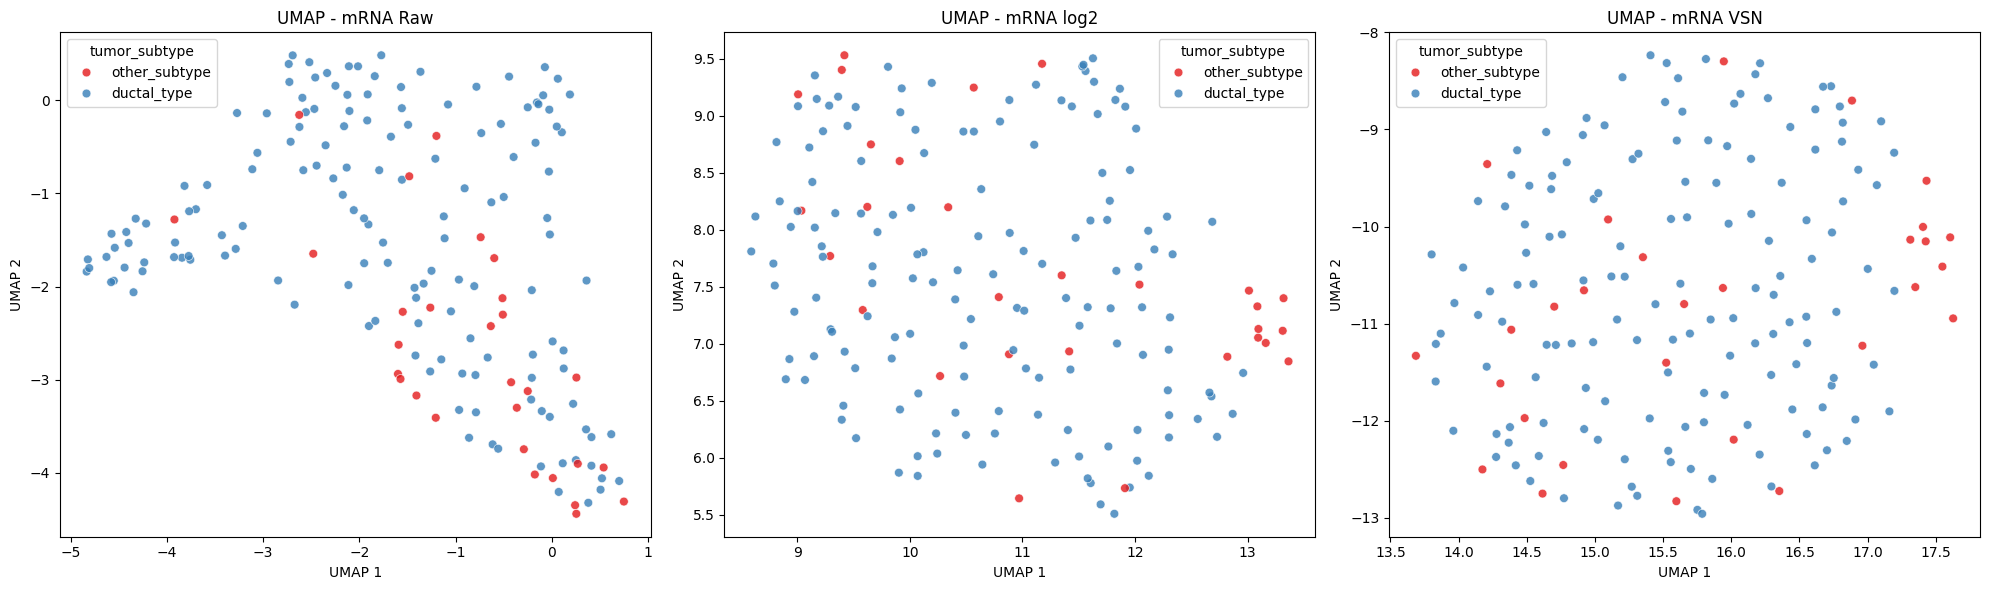

In [248]:
hue_orders = ['other_subtype', 'ductal_type']

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex = False, sharey = False)

plots = [(embedding_mrna, 'UMAP - mRNA Raw'),
         (embedding_mrna_lg2, 'UMAP - mRNA log2'),
         (embedding_mrna_vsn, 'UMAP - mRNA VSN')]

for i, (embedding, title) in enumerate(plots):
    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=subtype, palette = 'Set1', hue_order = hue_orders, s=40, alpha=0.8, ax=axes[i])
    axes[i].set_title(title)
    axes[i].set_xlabel('UMAP 1')
    axes[i].set_ylabel('UMAP 2')


plt.tight_layout()
plt.show()

#### UMAP on mirna_data, mirna_data_lg2 and mirna_data_vsn

In [249]:
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
embedding_mirna = umap_model.fit_transform(mirna_data)
embedding_mirna_lg2 = umap_model.fit_transform(mirna_data_lg2)
embedding_mirna_vsn = umap_model.fit_transform(mirna_data_vsn)

c:\Users\ritam\Desktop\thesis_rita\mofa_venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [250]:
subtype = clinical_data.loc[mirna_data.index, 'tumor_subtype']

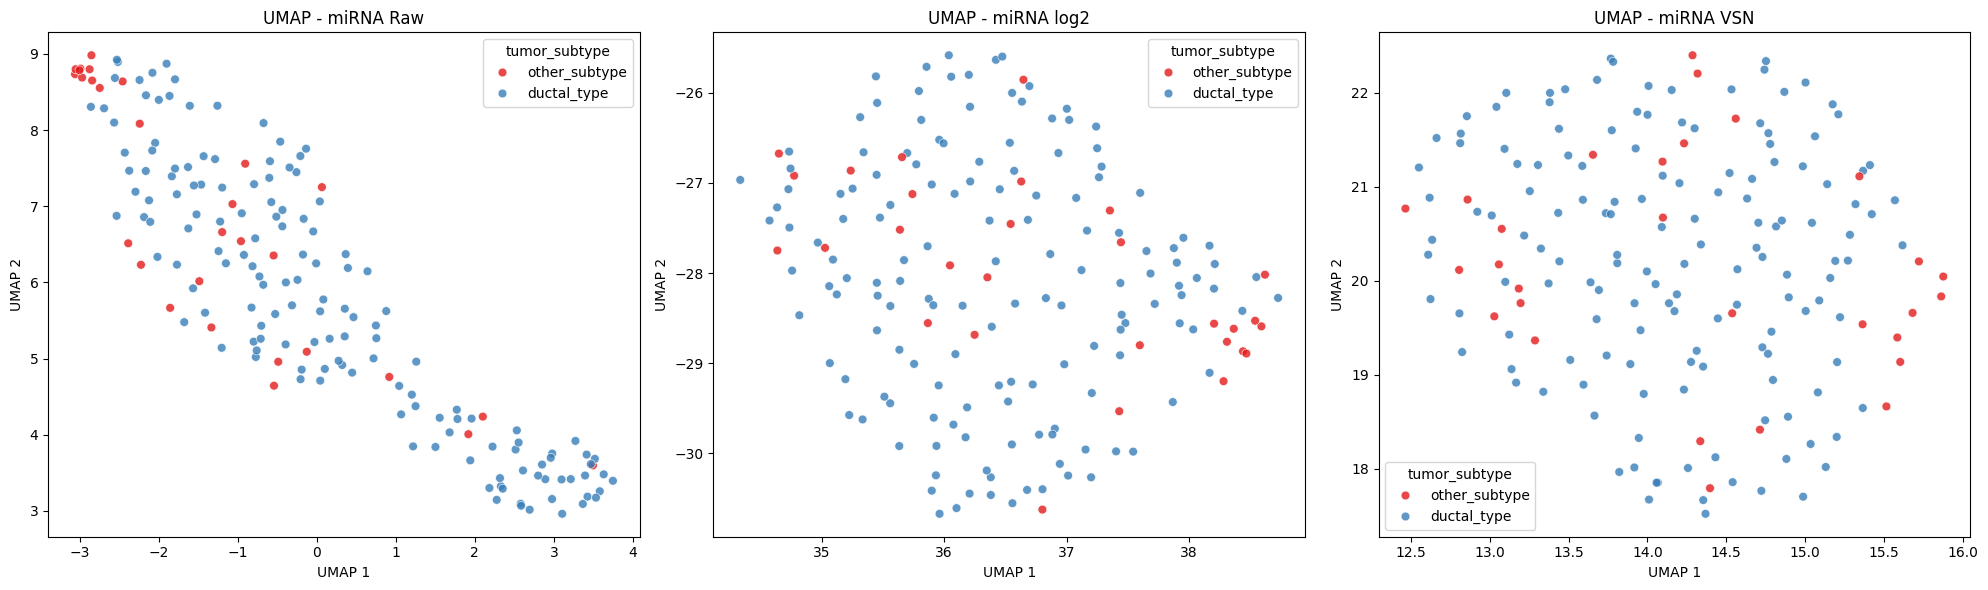

In [251]:
hue_orders = ['other_subtype', 'ductal_type']

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex = False, sharey = False)

plots = [(embedding_mirna, 'UMAP - miRNA Raw'),
         (embedding_mirna_lg2, 'UMAP - miRNA log2'),
         (embedding_mirna_vsn, 'UMAP - miRNA VSN')]

for i, (embedding, title) in enumerate(plots):
    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=subtype, palette = 'Set1', hue_order = hue_orders, s=40, alpha=0.8, ax=axes[i])
    axes[i].set_title(title)
    axes[i].set_xlabel('UMAP 1')
    axes[i].set_ylabel('UMAP 2')


plt.tight_layout()
plt.show()

### DNA Methylation: Convert Beta-Values into M-values

In [470]:
epsilon = 1e-6
meth_beta = meth_data.clip(lower=epsilon, upper = 1 - epsilon)
meth_data = np.log2(meth_beta / (1 - meth_beta))

In [471]:
meth_data.head(3)

,cg18147296,cg16352085,cg04839849,cg03725447,cg25215298,cg04672450,cg27487046,cg06091566,cg03735847,cg09166659,...,cg17074573,cg03403991,cg12502079,cg06422471,cg19324023,cg09635994,cg26034629,cg25232725,cg05615487,cg08423507
patient_id,,,,,,,,,,,,,,,,,,,,,
TCGA-2J-AABR,1.745914,-5.286278,-4.832093,-4.755929,-2.301503,-3.756853,-4.513866,-5.219603,-5.256874,-5.382266,...,2.760336,1.559789,0.563621,-1.072052,0.589803,3.755427,1.589870,1.365307,1.275649,2.220840
TCGA-FB-AAPS,0.739042,-5.024595,-4.373929,-4.074009,-1.535579,-3.135230,-4.890515,-3.315885,-5.930055,-5.351940,...,3.642541,1.960549,0.458102,-0.381046,0.425413,3.394619,2.114382,1.114411,1.345403,1.290225
TCGA-IB-AAUO,1.823719,-5.297343,-4.689793,-4.547699,-1.767795,-3.655213,-4.820569,-4.404958,-1.553639,-5.713093,...,3.863245,2.403640,1.381876,-0.221812,0.354457,4.557208,1.837971,1.976547,1.760156,3.833911


Save meth_data with M-values

In [472]:
meth_data.to_csv('../../data/transformed_data/meth_data_m_values.csv')

### Univariate Analysis

In [24]:
mrna_data_lg2 = pd.read_csv("../../data/transformed_data//mrna_data_lg2.csv", index_col=0)
mrna_data_vsn = pd.read_csv("../../data/transformed_data/mrna_data_vsn.csv", index_col=0)
mirna_data_lg2 = pd.read_csv("../../data/transformed_data/mirna_data_lg2.csv", index_col=0)
mirna_data_vsn = pd.read_csv("../../data/transformed_data/mirna_data_vsn.csv", index_col=0)
meth_data = pd.read_csv("../../data/transformed_data/meth_data_m_values.csv", index_col=0)

In [25]:
clinical_data = pd.read_csv('../../data/cleaned_data/clinical_cleaned.csv', index_col=0)

Set the omics datasets aligned with clinical dataset

In [26]:
mrna_data_lg2 = mrna_data_lg2.loc[clinical_data.index]
mirna_data_lg2 = mirna_data_lg2.loc[clinical_data.index]
mrna_data_vsn = mrna_data_vsn.loc[clinical_data.index]
mirna_data_vsn = mirna_data_vsn.loc[clinical_data.index]
meth_data = meth_data.loc[clinical_data.index]

In [27]:
y = clinical_data['tumor_subtype'].map({'other_subtype': 0, 'ductal_type': 1})

#### Function for feature selection - Logistic Regression, Hypothesis Test using B-H correction

In [28]:
def select_omics_features(omics_data, target, alpha=0.2):
    p_values = []
    features = omics_data.columns

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        for feature in features:
            X = omics_data[feature]
            X = sm.add_constant(X)

            try:
                model = sm.Logit(target, X).fit(disp=0)
                p_val = model.pvalues.iloc[1]
            except Exception:
                p_val = 1.0

            p_values.append(p_val)
    
    reject, pvals_corrected, _, _ = multipletests(p_values, alpha=alpha, method='fdr_bh')

    significant_features = features[reject]
    filtered_data = omics_data[significant_features]

    print(f"Selected {len(significant_features)} features out of {len(features)} with alpha={alpha}")
    return filtered_data

#### Feature Selection - mrna_data_lg2

In [29]:
selected_features_mrna_data_lg2 = select_omics_features(mrna_data_lg2, y)

Selected 12819 features out of 43404 with alpha=0.2


### Feature Selection - mrna_data_vsn

In [30]:
selected_features_mrna_data_vsn = select_omics_features(mrna_data_vsn, y)

Selected 9907 features out of 43404 with alpha=0.2


### Feature Selection - mirna_data_lg2

In [31]:
selected_features_mirna_data_lg2 = select_omics_features(mirna_data_lg2, y)

Selected 298 features out of 982 with alpha=0.2


### Feature Selection - mirna_data_vsn

In [32]:
selected_features_mirna_data_vsn = select_omics_features(mirna_data_vsn, y)

Selected 198 features out of 982 with alpha=0.2


### Feature Selection - meth_data

In [33]:
selected_features_meth_data = select_omics_features(meth_data, y)

Selected 60869 features out of 194313 with alpha=0.2


#### Save datasets after feature selection

In [34]:
selected_features_mrna_data_lg2.to_csv('../../data/feature_selection/selected_features_mrna_data_lg2.csv')

In [35]:
selected_features_mrna_data_vsn.to_csv('../../data/feature_selection/selected_features_mrna_data_vsn.csv')

In [36]:
selected_features_mirna_data_lg2.to_csv('../../data/feature_selection/selected_features_mirna_data_lg2.csv')

In [37]:
selected_features_mirna_data_vsn.to_csv('../../data/feature_selection/selected_features_mirna_data_vsn.csv')

In [38]:
selected_features_meth_data.to_csv('../../data/feature_selection/selected_features_meth_data.csv')